# Artifact Detection in AI-Generated Face Images

**Task:** Binary classification to detect artifacts (bad hands, text, mask fragments, tattoos, eye issues) in AI-generated face images.

**Approaches:**
1. EfficientNet-B0 (texture/local features)
2. ViT-B/16 (semantic/global features)
3. Weighted ensemble of both

**Primary metric:** Macro F1 Score

**Class imbalance handling:**
- WeightedRandomSampler (oversamples minority class)
- Weighted CrossEntropyLoss (9:1 weighting)
- Threshold optimization on validation set

In [2]:
import sys
import os

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter

from config import TRAIN_DIR, TEST_DIR, CLASS_NAMES, SEED
from utils import set_seed, get_file_list, get_device

set_seed(SEED)
device = get_device()
print(f"Device: {device}")

Device: mps


## 1. Exploratory Data Analysis

Train: 1800 images
  Class 0 (artifact): 180
  Class 1 (clean):    1620

Test: 200 images
  Class 0 (artifact): 20
  Class 1 (clean):    180


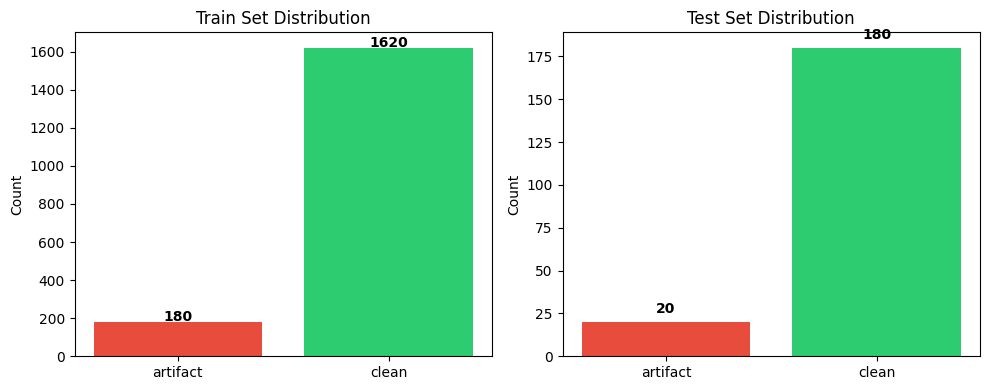

In [3]:
# Class distribution
train_files = get_file_list(TRAIN_DIR)
test_files = get_file_list(TEST_DIR)

train_labels = [f[1] for f in train_files]
test_labels = [f[1] for f in test_files]

print(f"Train: {len(train_files)} images")
print(f"  Class 0 (artifact): {train_labels.count(0)}")
print(f"  Class 1 (clean):    {train_labels.count(1)}")
print(f"\nTest: {len(test_files)} images")
print(f"  Class 0 (artifact): {test_labels.count(0)}")
print(f"  Class 1 (clean):    {test_labels.count(1)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, labels, title in zip(axes, [train_labels, test_labels], ["Train", "Test"]):
    counts = Counter(labels)
    ax.bar([CLASS_NAMES[0], CLASS_NAMES[1]], [counts[0], counts[1]], color=["#e74c3c", "#2ecc71"])
    ax.set_title(f"{title} Set Distribution")
    ax.set_ylabel("Count")
    for i, (cls, count) in enumerate(sorted(counts.items())):
        ax.text(i, count + 5, str(count), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

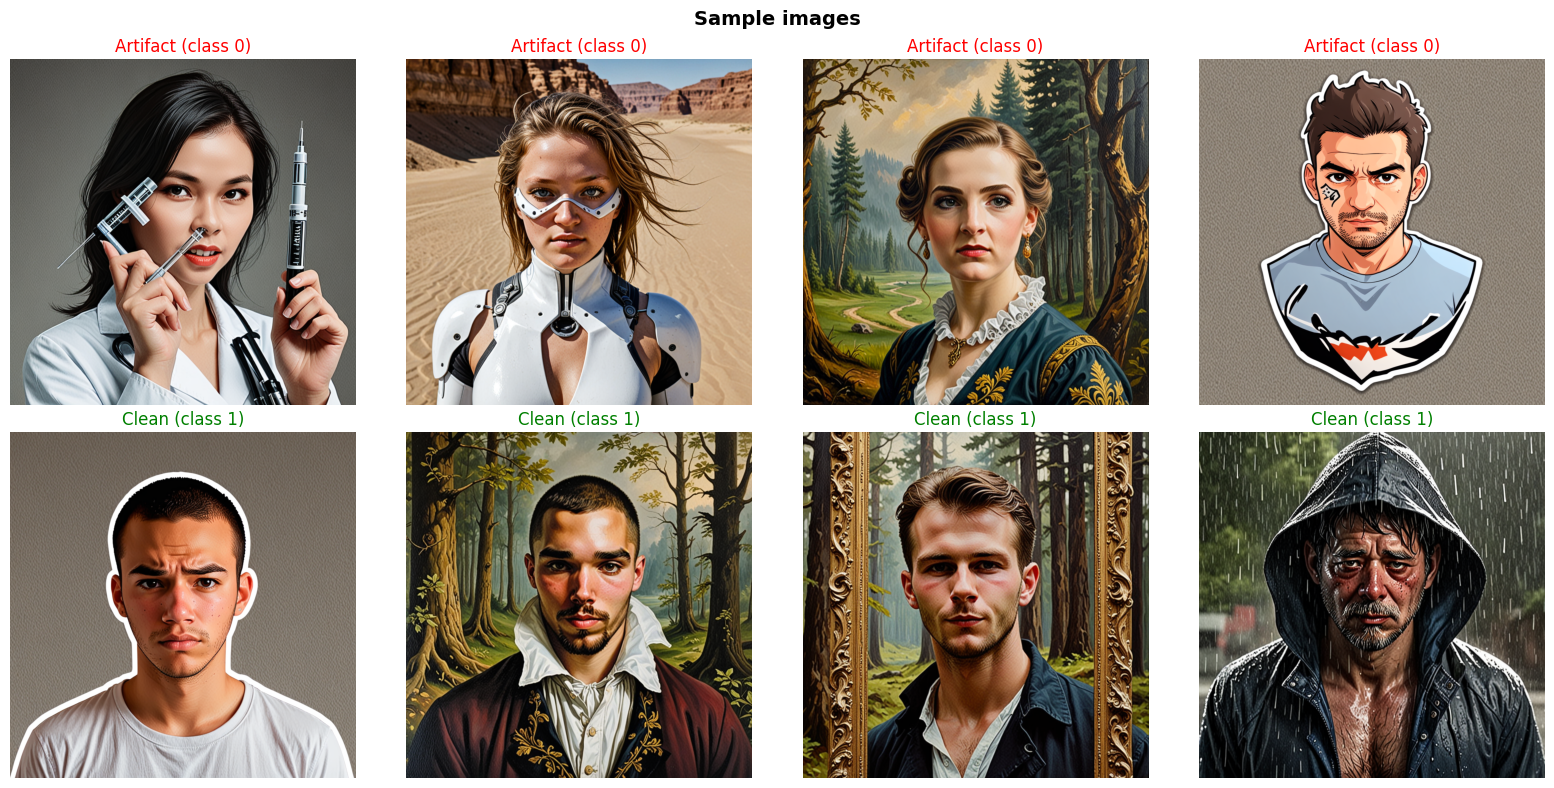

In [4]:
# Sample images from each class
artifact_files = [f for f in train_files if f[1] == 0]
clean_files = [f for f in train_files if f[1] == 1]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Sample images", fontsize=14, fontweight="bold")

np.random.seed(SEED)
for i, fp in enumerate(np.random.choice(len(artifact_files), 4, replace=False)):
    img = mpimg.imread(artifact_files[fp][0])
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Artifact (class 0)", color="red")
    axes[0, i].axis("off")

for i, idx in enumerate(np.random.choice(len(clean_files), 4, replace=False)):
    img = mpimg.imread(clean_files[idx][0])
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Clean (class 1)", color="green")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## 2. Train/Val Split Verification

In [5]:
from dataset import split_train_val

train_split, val_split = split_train_val()
train_split_labels = [f[1] for f in train_split]
val_split_labels = [f[1] for f in val_split]

print(f"Train split: {len(train_split)} images")
print(f"  Class 0: {train_split_labels.count(0)} ({train_split_labels.count(0)/len(train_split)*100:.1f}%)")
print(f"  Class 1: {train_split_labels.count(1)} ({train_split_labels.count(1)/len(train_split)*100:.1f}%)")
print(f"\nVal split: {len(val_split)} images")
print(f"  Class 0: {val_split_labels.count(0)} ({val_split_labels.count(0)/len(val_split)*100:.1f}%)")
print(f"  Class 1: {val_split_labels.count(1)} ({val_split_labels.count(1)/len(val_split)*100:.1f}%)")

/Users/lilianamirchuk/Desktop/it_jim_genai_course/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train split: 1530 images
  Class 0: 153 (10.0%)
  Class 1: 1377 (90.0%)

Val split: 270 images
  Class 0: 27 (10.0%)
  Class 1: 243 (90.0%)


In [6]:
import sys
print(sys.executable)

/Users/lilianamirchuk/Desktop/it_jim_genai_course/.venv/bin/python


## 3. Approach 1: EfficientNet-B0

Fine-tuned EfficientNet-B0 (pretrained on ImageNet). Good at capturing texture and local patterns like bad hands, mask edges, etc.
- Input: 384x384
- Frozen backbone for first 3 epochs, then gradual unfreezing with differential LR

In [7]:
from train import train_model

results_eff = train_model("efficientnet")

/Users/lilianamirchuk/Desktop/it_jim_genai_course/.venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/Users/lilianamirchuk/Desktop/it_jim_genai_course/lab_1/dataset.py:68: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(



Training EFFICIENTNET | device=mps | img_size=384

Epoch 1/30


  train_loss=0.8308  val_loss=1.7838  val_f1=0.3363  lr=1.00e-03

Epoch 2/30


  train_loss=0.6232  val_loss=1.8475  val_f1=0.3604  lr=1.00e-03

Epoch 3/30


  train_loss=0.5499  val_loss=1.4788  val_f1=0.4289  lr=1.00e-03

>> Unfreezing backbone at epoch 4

Epoch 4/30


...

  train_loss=0.1490  val_loss=0.6651  val_f1=0.6616  lr=1.03e-04

Epoch 26/30


  train_loss=0.1415  val_loss=0.6808  val_f1=0.6743  lr=6.70e-05

Epoch 27/30


  train_loss=0.1378  val_loss=0.6705  val_f1=0.6743  lr=3.81e-05

Epoch 28/30


  train_loss=0.1545  val_loss=0.7212  val_f1=0.6856  lr=1.70e-05

Epoch 29/30


  train_loss=0.1530  val_loss=0.6668  val_f1=0.7149  lr=4.28e-06

Early stopping at epoch 29. Best val F1: 0.7313

Best model saved to /Users/lilianamirchuk/Desktop/it_jim_genai_course/lab_1/outputs/checkpoints/best_efficientnet.pth
Best val macro F1: 0.7313


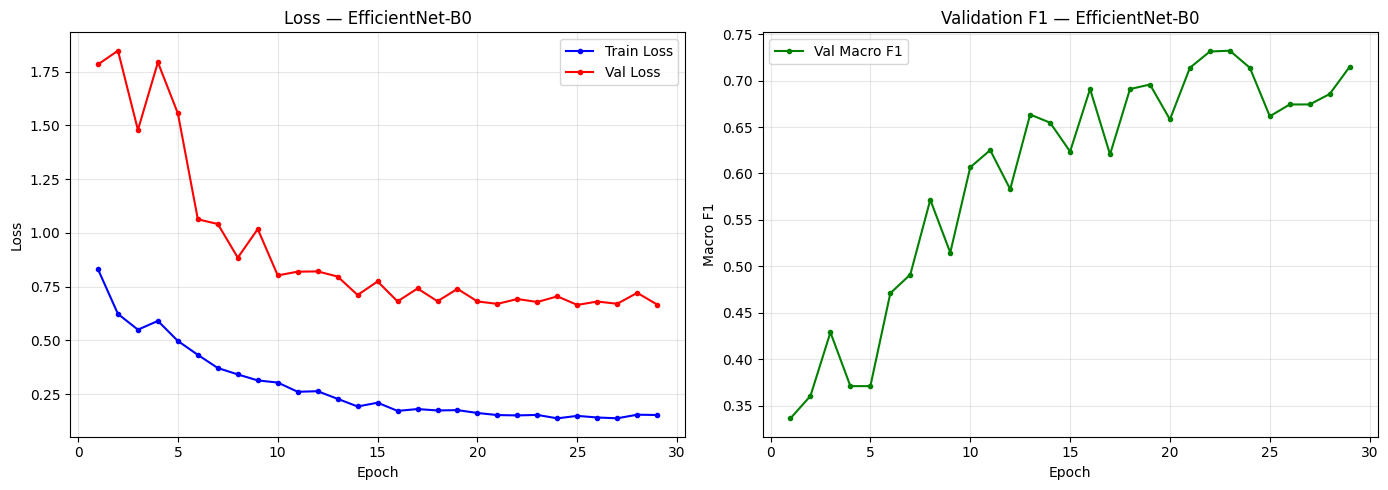

In [8]:
from evaluate import plot_training_history

fig = plot_training_history(results_eff["history"], title="EfficientNet-B0")
plt.show()

### EfficientNet-B0 — Validation Evaluation

In [9]:
import torch
from evaluate import predict_probs, full_evaluation, optimize_threshold
from evaluate import plot_threshold_curve, plot_confusion_matrix, plot_roc_pr_curves
from dataset import get_dataloaders
from config import IMG_SIZE_EFFICIENTNET, IMG_SIZE_VIT

# Get validation predictions for EfficientNet
dataloaders_eff = get_dataloaders(img_size=IMG_SIZE_EFFICIENTNET)
eff_model = results_eff["model"].to(device)
val_labels_eff, val_probs_eff, _ = predict_probs(eff_model, dataloaders_eff["val"], device)

# Threshold optimization
eff_thresh, eff_val_f1 = optimize_threshold(val_labels_eff, val_probs_eff)
print(f"Optimal threshold: {eff_thresh:.2f}, Val Macro F1: {eff_val_f1:.4f}")

# Full evaluation at optimal threshold
eff_val_results = full_evaluation(val_labels_eff, val_probs_eff, "EfficientNet-B0 (val)", threshold=eff_thresh)

/Users/lilianamirchuk/Desktop/it_jim_genai_course/.venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/Users/lilianamirchuk/Desktop/it_jim_genai_course/lab_1/dataset.py:68: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(
                                                           

Optimal threshold: 0.25, Val Macro F1: 0.7757

Evaluation: EfficientNet-B0 (val)
Optimal threshold: 0.25
Macro F1: 0.7757
ROC-AUC: 0.8839

              precision    recall  f1-score   support

    artifact       0.50      0.78      0.61        27
       clean       0.97      0.91      0.94       243

    accuracy                           0.90       270
   macro avg       0.74      0.85      0.78       270
weighted avg       0.93      0.90      0.91       270

Confusion Matrix:
[[ 21   6]
 [ 21 222]]


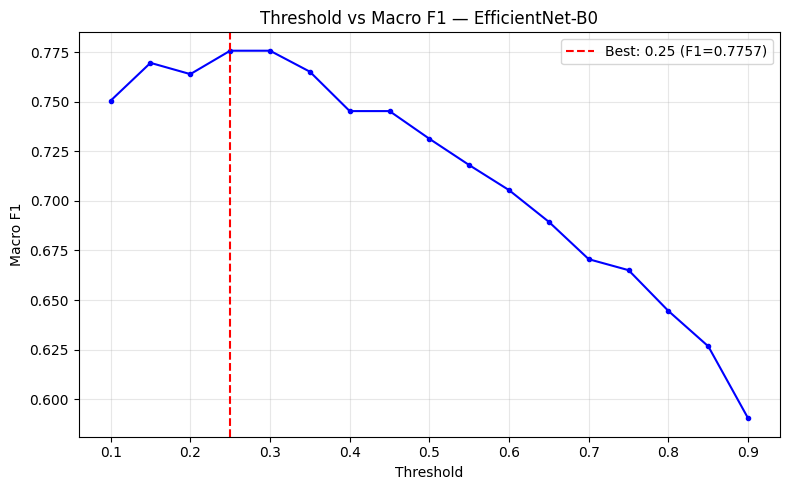

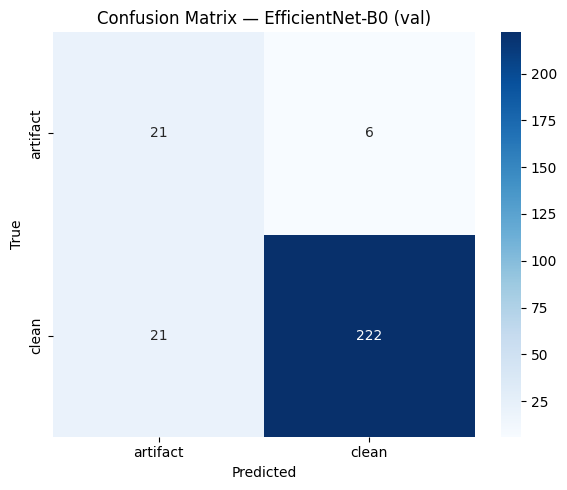

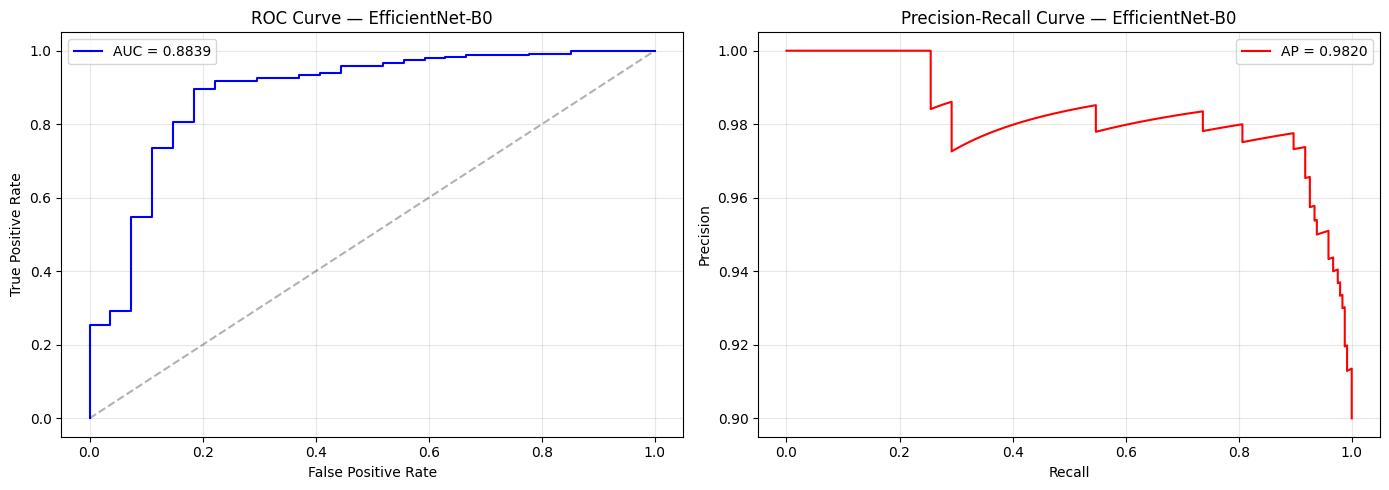

In [10]:
# Plots for EfficientNet
fig1 = plot_threshold_curve(val_labels_eff, val_probs_eff, "EfficientNet-B0")
plt.show()

fig2 = plot_confusion_matrix(eff_val_results["confusion_matrix"], "EfficientNet-B0 (val)")
plt.show()

fig3 = plot_roc_pr_curves(val_labels_eff, val_probs_eff, "EfficientNet-B0")
plt.show()

## 4. Approach 2: ViT-B/16

Fine-tuned Vision Transformer (pretrained on ImageNet-21K). Strong at capturing global/semantic features like text overlays, unusual compositions, and eye direction anomalies.
- Input: 224x224
- Frozen backbone for first 3 epochs, then gradual unfreezing

In [11]:
results_vit = train_model("vit")

/Users/lilianamirchuk/Desktop/it_jim_genai_course/.venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/Users/lilianamirchuk/Desktop/it_jim_genai_course/lab_1/dataset.py:68: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(



Training VIT | device=mps | img_size=224

Epoch 1/30


  train_loss=0.3348  val_loss=0.6939  val_f1=0.4559  lr=1.00e-03

Epoch 2/30


  train_loss=0.2114  val_loss=0.5027  val_f1=0.5802  lr=1.00e-03

Epoch 3/30


  train_loss=0.1889  val_loss=0.6470  val_f1=0.4895  lr=1.00e-03

>> Unfreezing backbone at epoch 4

Epoch 4/30


...

  train_loss=0.0378  val_loss=1.1312  val_f1=0.8222  lr=8.04e-04

Epoch 14/30


  train_loss=0.0580  val_loss=0.8810  val_f1=0.7875  lr=7.50e-04

Epoch 15/30


  train_loss=0.0335  val_loss=0.8517  val_f1=0.8279  lr=6.91e-04

Epoch 16/30


  train_loss=0.0550  val_loss=0.6278  val_f1=0.7596  lr=6.29e-04

Epoch 17/30


  train_loss=0.0373  val_loss=1.0499  val_f1=0.8279  lr=5.65e-04

Early stopping at epoch 17. Best val F1: 0.8431

Best model saved to /Users/lilianamirchuk/Desktop/it_jim_genai_course/lab_1/outputs/checkpoints/best_vit.pth
Best val macro F1: 0.8431


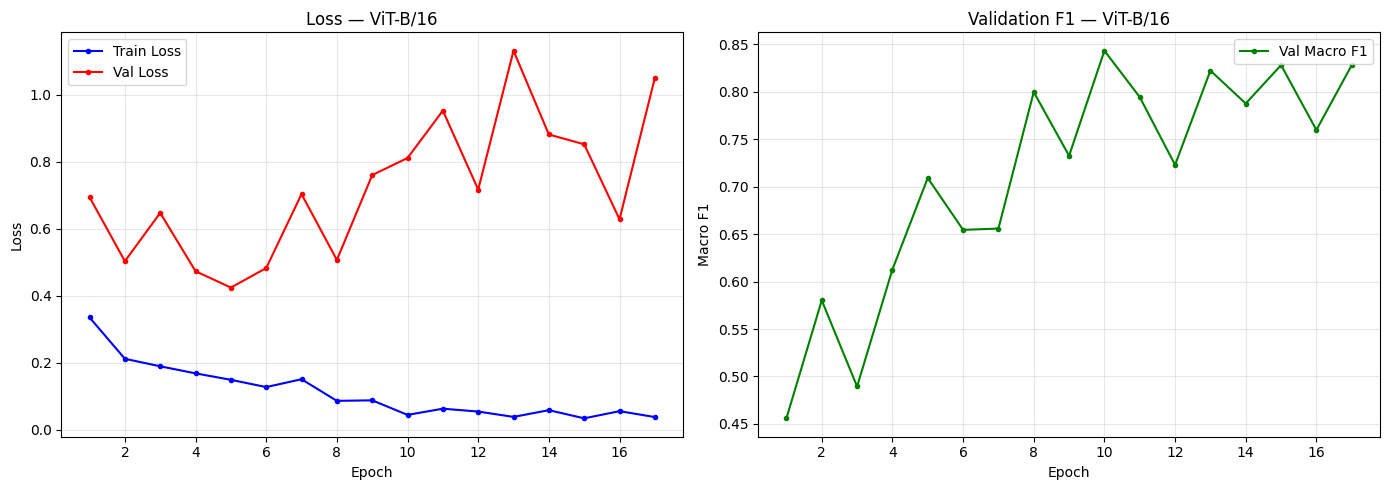

In [12]:
fig = plot_training_history(results_vit["history"], title="ViT-B/16")
plt.show()

### ViT-B/16 — Validation Evaluation

In [13]:
# Get validation predictions for ViT
dataloaders_vit = get_dataloaders(img_size=IMG_SIZE_VIT)
vit_model = results_vit["model"].to(device)
val_labels_vit, val_probs_vit, _ = predict_probs(vit_model, dataloaders_vit["val"], device)

# Threshold optimization
vit_thresh, vit_val_f1 = optimize_threshold(val_labels_vit, val_probs_vit)
print(f"Optimal threshold: {vit_thresh:.2f}, Val Macro F1: {vit_val_f1:.4f}")

# Full evaluation at optimal threshold
vit_val_results = full_evaluation(val_labels_vit, val_probs_vit, "ViT-B/16 (val)", threshold=vit_thresh)

/Users/lilianamirchuk/Desktop/it_jim_genai_course/.venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/Users/lilianamirchuk/Desktop/it_jim_genai_course/lab_1/dataset.py:68: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(
                                                           

Optimal threshold: 0.15, Val Macro F1: 0.8574

Evaluation: ViT-B/16 (val)
Optimal threshold: 0.15
Macro F1: 0.8574
ROC-AUC: 0.9214

              precision    recall  f1-score   support

    artifact       0.89      0.63      0.74        27
       clean       0.96      0.99      0.98       243

    accuracy                           0.96       270
   macro avg       0.93      0.81      0.86       270
weighted avg       0.95      0.96      0.95       270

Confusion Matrix:
[[ 17  10]
 [  2 241]]


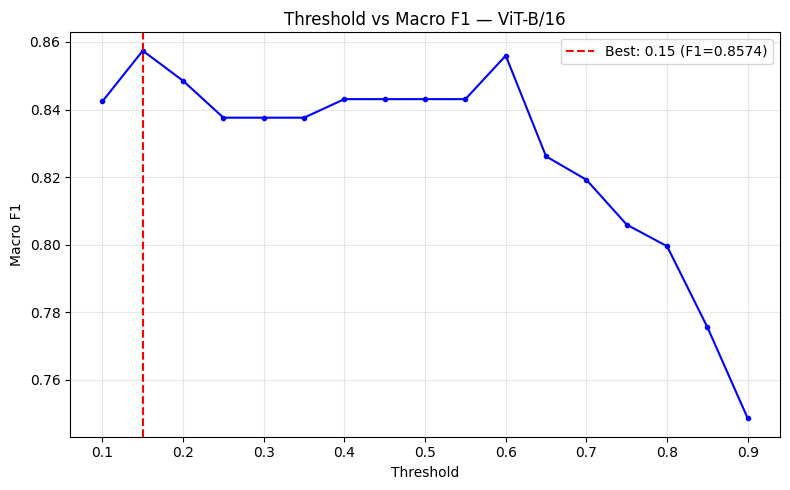

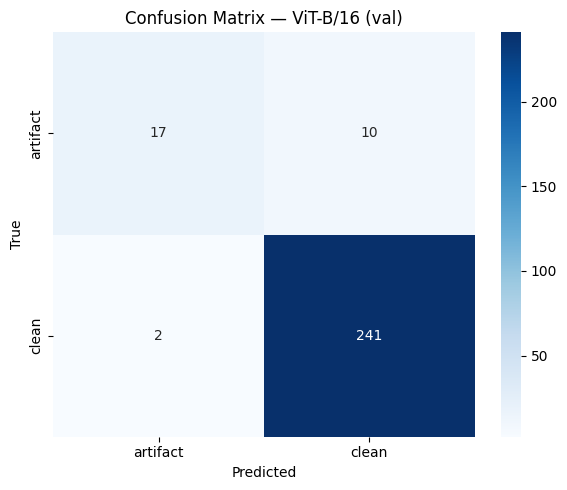

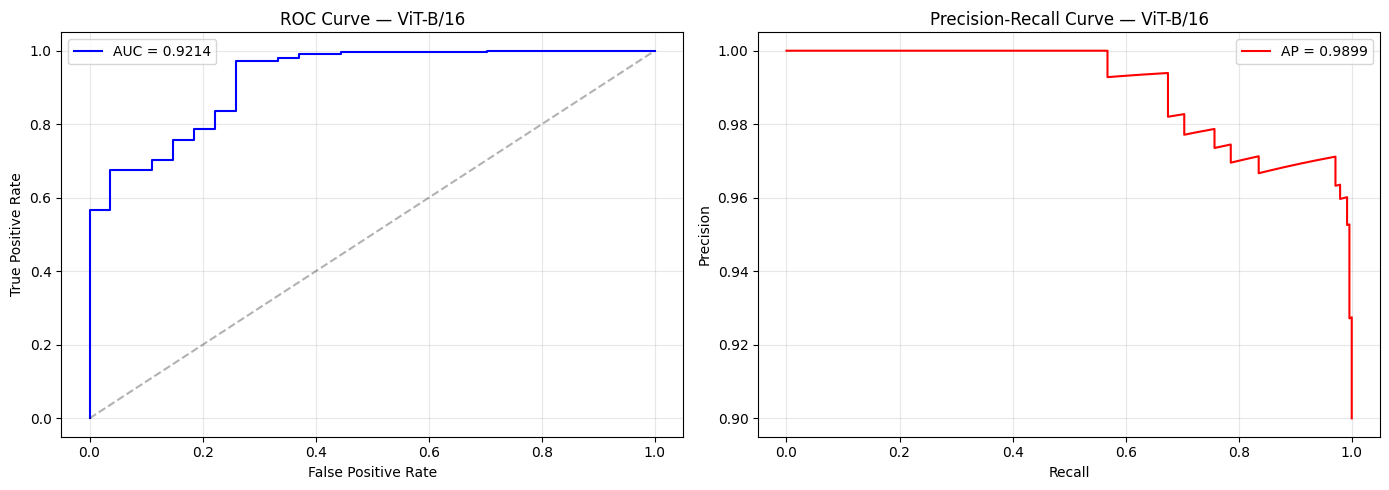

In [14]:
# Plots for ViT
fig1 = plot_threshold_curve(val_labels_vit, val_probs_vit, "ViT-B/16")
plt.show()

fig2 = plot_confusion_matrix(vit_val_results["confusion_matrix"], "ViT-B/16 (val)")
plt.show()

fig3 = plot_roc_pr_curves(val_labels_vit, val_probs_vit, "ViT-B/16")
plt.show()

## 5. Ensemble

Weighted average ensemble combining EfficientNet-B0 and ViT-B/16 predictions. Weights are proportional to each model's validation macro F1 score. Threshold is re-optimized on the combined validation probabilities.

In [15]:
from ensemble import weighted_average_ensemble, run_ensemble

# Ensemble on validation set first
val_probs_combined = weighted_average_ensemble(
    [val_probs_eff, val_probs_vit],
    weights=[eff_val_f1, vit_val_f1],
)
ens_thresh, ens_val_f1 = optimize_threshold(val_labels_eff, val_probs_combined)
print(f"Ensemble optimal threshold: {ens_thresh:.2f}, Val Macro F1: {ens_val_f1:.4f}")

ens_val_results = full_evaluation(
    val_labels_eff, val_probs_combined, "ensemble (val)", threshold=ens_thresh
)

Ensemble optimal threshold: 0.35, Val Macro F1: 0.8678

Evaluation: ensemble (val)
Optimal threshold: 0.35
Macro F1: 0.8678
ROC-AUC: 0.9178

              precision    recall  f1-score   support

    artifact       0.83      0.70      0.76        27
       clean       0.97      0.98      0.98       243

    accuracy                           0.96       270
   macro avg       0.90      0.84      0.87       270
weighted avg       0.95      0.96      0.95       270

Confusion Matrix:
[[ 19   8]
 [  4 239]]


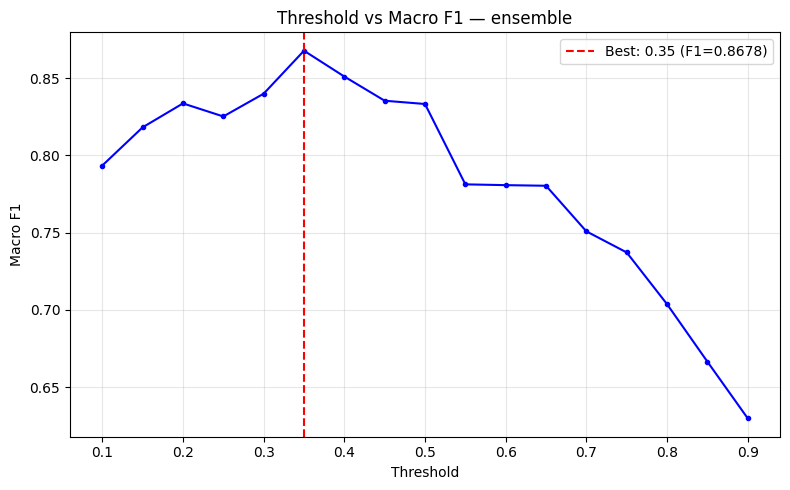

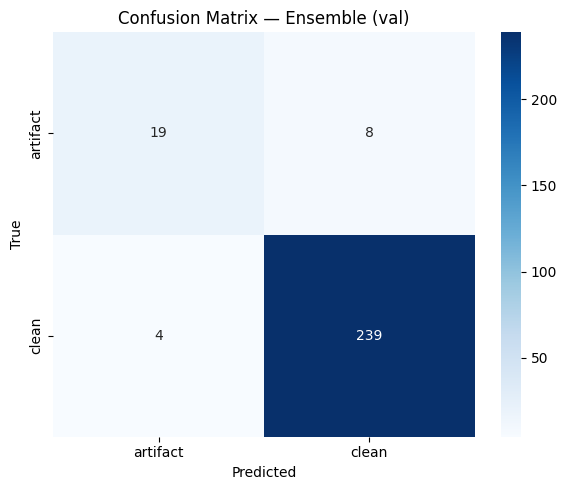

In [16]:
# Ensemble validation plots
fig1 = plot_threshold_curve(val_labels_eff, val_probs_combined, "ensemble")
plt.show()

fig2 = plot_confusion_matrix(ens_val_results["confusion_matrix"], "Ensemble (val)")
plt.show()

## 6. Validation Comparison

In [17]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["EfficientNet-B0", "ViT-B/16", "Ensemble"],
    "Val Macro F1": [eff_val_f1, vit_val_f1, ens_val_f1],
    "Threshold": [eff_thresh, vit_thresh, ens_thresh],
    "Val ROC-AUC": [
        eff_val_results["roc_auc"],
        vit_val_results["roc_auc"],
        ens_val_results["roc_auc"],
    ],
})
print("Validation results comparison")
print(comparison.to_string(index=False))

Validation results comparison
          Model  Val Macro F1  Threshold  Val ROC-AUC
EfficientNet-B0      0.775685       0.25     0.883859
       ViT-B/16      0.857419       0.15     0.921353
       Ensemble      0.867755       0.35     0.917848


## 7. Test Set Inference

Running all three approaches (EfficientNet, ViT, Ensemble) on the held-out test set with optimized thresholds from validation.

In [18]:
from inference import run_inference

# EfficientNet on test set
print("EfficientNet-B0: test set")
test_eff = run_inference("efficientnet", threshold=eff_thresh)

EfficientNet-B0: test set



Evaluation: efficientnet (test)
Optimal threshold: 0.25
Macro F1: 0.7872
ROC-AUC: 0.8600

              precision    recall  f1-score   support

    artifact       0.56      0.70      0.62        20
       clean       0.97      0.94      0.95       180

    accuracy                           0.92       200
   macro avg       0.76      0.82      0.79       200
weighted avg       0.93      0.92      0.92       200

Confusion Matrix:
[[ 14   6]
 [ 11 169]]
Predictions saved to /Users/lilianamirchuk/Desktop/it_jim_genai_course/lab_1/outputs/predictions_efficientnet.csv


In [19]:
# ViT on test set
print("ViT-B/16: test set")
test_vit = run_inference("vit", threshold=vit_thresh)

ViT-B/16: test set



Evaluation: vit (test)
Optimal threshold: 0.15
Macro F1: 0.8302
ROC-AUC: 0.8722

              precision    recall  f1-score   support

    artifact       0.92      0.55      0.69        20
       clean       0.95      0.99      0.97       180

    accuracy                           0.95       200
   macro avg       0.93      0.77      0.83       200
weighted avg       0.95      0.95      0.94       200

Confusion Matrix:
[[ 11   9]
 [  1 179]]
Predictions saved to /Users/lilianamirchuk/Desktop/it_jim_genai_course/lab_1/outputs/predictions_vit.csv


In [20]:
# Ensemble on test set
print("Ensemble: test set")
test_ens = run_ensemble(eff_val_f1, vit_val_f1)

Ensemble: test set
Getting validation predictions for threshold tuning...


Ensemble optimal threshold on val: 0.35 (F1=0.8678)

Running ensemble on test set...



Evaluation: Ensemble (test)
Optimal threshold: 0.35
Macro F1: 0.8183
ROC-AUC: 0.8739

              precision    recall  f1-score   support

    artifact       0.85      0.55      0.67        20
       clean       0.95      0.99      0.97       180

    accuracy                           0.94       200
   macro avg       0.90      0.77      0.82       200
weighted avg       0.94      0.94      0.94       200

Confusion Matrix:
[[ 11   9]
 [  2 178]]
Ensemble predictions saved to /Users/lilianamirchuk/Desktop/it_jim_genai_course/lab_1/outputs/predictions_ensemble.csv


## 8. Final Results Summary

In [21]:
# Final comparison table
final_comparison = pd.DataFrame({
    "Model": ["EfficientNet-B0", "ViT-B/16", "Ensemble"],
    "Val Macro F1": [eff_val_f1, vit_val_f1, ens_val_f1],
    "Test Macro F1": [
        test_eff["macro_f1"],
        test_vit["macro_f1"],
        test_ens["macro_f1"],
    ],
    "Test ROC-AUC": [
        test_eff["roc_auc"],
        test_vit["roc_auc"],
        test_ens["roc_auc"],
    ],
    "Threshold": [eff_thresh, vit_thresh, test_ens["threshold"]],
})

print("Final results copmarison")
print(final_comparison.to_string(index=False))

best_idx = final_comparison["Test Macro F1"].idxmax()
best_model = final_comparison.loc[best_idx, "Model"]
best_f1 = final_comparison.loc[best_idx, "Test Macro F1"]
print(f"\nBest model: {best_model} with Test Macro F1 = {best_f1:.4f}")

Final results copmarison
          Model  Val Macro F1  Test Macro F1  Test ROC-AUC  Threshold
EfficientNet-B0      0.775685       0.787167      0.860000       0.25
       ViT-B/16      0.857419       0.830163      0.872222       0.15
       Ensemble      0.867755       0.818347      0.873889       0.35

Best model: ViT-B/16 with Test Macro F1 = 0.8302


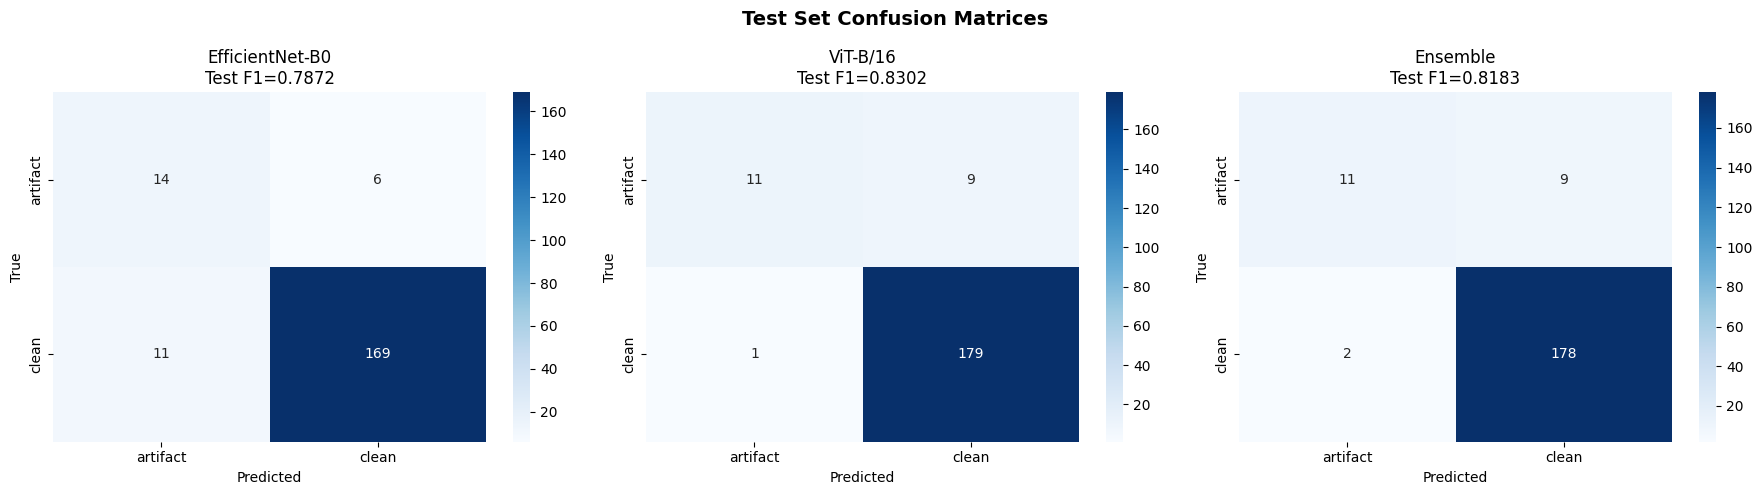

In [22]:
# Test confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
import seaborn as sns

for ax, (name, results) in zip(axes, [
    ("EfficientNet-B0", test_eff),
    ("ViT-B/16", test_vit),
    ("Ensemble", test_ens),
]):
    from config import CLASS_NAMES
    sns.heatmap(
        results["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
        xticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]],
        yticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]],
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{name}\nTest F1={results['macro_f1']:.4f}")

plt.suptitle("Test Set Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Misclassified Images Analysis

Inspecting images that the best model got wrong to understand failure modes.

misclassified images: 11 / 200


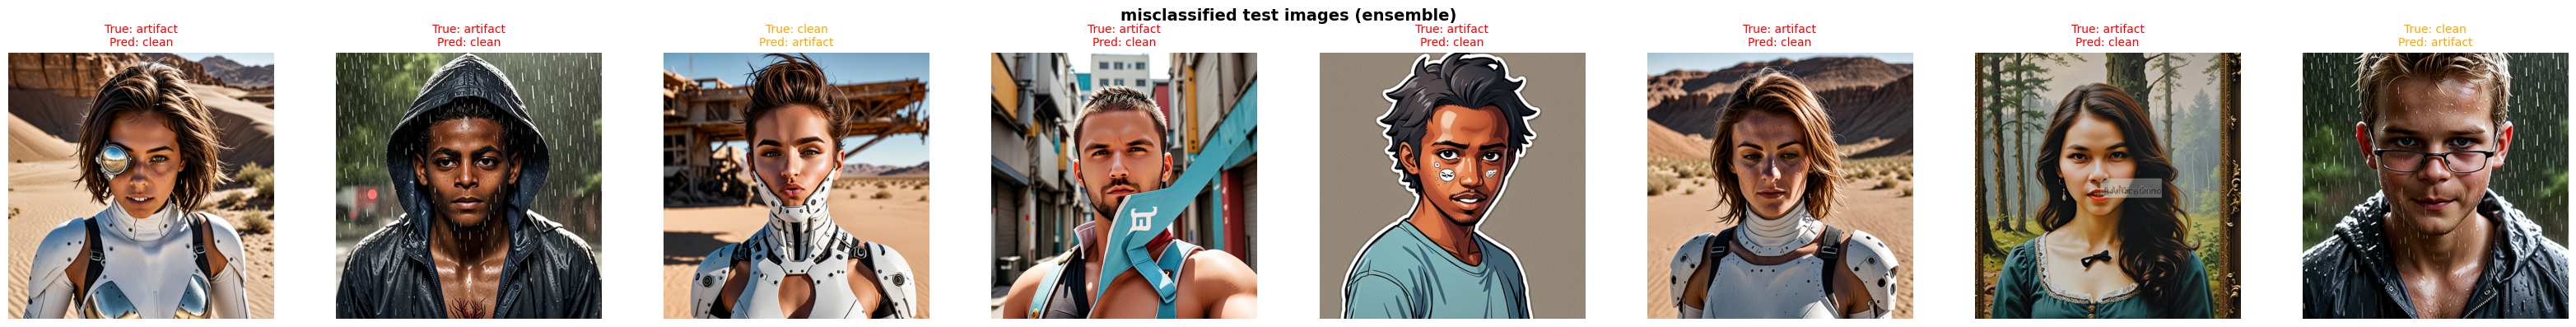

In [23]:
# show misclassified test images from ensemble
ens_df = test_ens["dataframe"]
misclassified = ens_df[ens_df["true_label"] != ens_df["predicted_label"]]
print(f"misclassified images: {len(misclassified)} / {len(ens_df)}")

if len(misclassified) > 0:
    n_show = min(8, len(misclassified))
    fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
    if n_show == 1:
        axes = [axes]
    
    for i, (_, row) in enumerate(misclassified.head(n_show).iterrows()):
        img_path = os.path.join(TEST_DIR, row["filename"])
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        true_cls = CLASS_NAMES[int(row["true_label"])]
        pred_cls = CLASS_NAMES[int(row["predicted_label"])]
        axes[i].set_title(f"True: {true_cls}\nPred: {pred_cls}", fontsize=10,
                         color="red" if row["true_label"] == 0 else "orange")
        axes[i].axis("off")
    
    plt.suptitle("misclassified test images (ensemble)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("no misclassifications on the test set")

## 10. Conclusion

**Summary of approaches:**

| Component | Details |
|---|---|
| **Approach 1** | EfficientNet-B0 (ImageNet pretrained, 384x384 input) — captures local texture artifacts |
| **Approach 2** | ViT-B/16 (ImageNet-21K pretrained, 224x224 input) — captures global semantic artifacts |
| **Ensemble** | Weighted probability averaging (weights = val F1 scores) with re-optimized threshold |
| **Imbalance handling** | WeightedRandomSampler + weighted CrossEntropyLoss (9:1) + threshold optimization |
| **Augmentation** | HorizontalFlip, ShiftScaleRotate, ColorJitter, GaussNoise, CoarseDropout |
| **Training** | AdamW, CosineAnnealing LR, frozen backbone warm-up, early stopping on val F1 |

**Key takeaways:**
- Threshold optimization is critical for macro F1 on imbalanced data — the optimal threshold is typically well below 0.5
- The ensemble combines complementary strengths: EfficientNet for texture/edge artifacts and ViT for semantic anomalies
- With only 180 artifact examples in training, careful data augmentation and balanced sampling prevent the model from ignoring the minority class